# Comparative Autoregressive (Rolling) Error Analysis: GINO vs FNO
This notebook analyzes and compares the error accumulation over time for Initial-Value Problem (IVP) rolling predictions between GINO and FNO models.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import os

# Set a nice plotting style
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})


## 1. Load Data


In [2]:
# GINO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/GINO_predictions/var_loss/resolution_1.0/gino_predictions_20260817_161903/rolling_sequence')
GINO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/GINO_predictions/standard/resolution_1.0/gino_predictions_20260818_093327/rolling_sequence')
FNO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/FNO_predictions/forcing/resolution_1.0/fno_predictions_20260818_085739/rolling_sequence')
# FFNO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/FNO_predictions/forcing_4d/resolution_1.0/fno_predictions_20260825_162600/rolling_sequence')
FFNO_RESULTS_DIR = Path('/scratch/yl75/ak4177/results/groundwater/FNO_predictions/forcing_4d/resolution_1.0/fno_predictions_20260828_141818/rolling_sequence')

# Load metadata
with open(GINO_RESULTS_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)
    
target_cols = metadata.get('args', {}).get('target_cols', ['mass_concentration', 'head'])
print(f"Target columns: {target_cols}")

print("Loading arrays (this may take a moment)...")
gino_preds = np.load(GINO_RESULTS_DIR / 'val_predictions.npy')
fno_preds = np.load(FNO_RESULTS_DIR / 'val_predictions.npy')
ffno_preds = np.load(FFNO_RESULTS_DIR / 'val_predictions.npy')
targets = np.load(FNO_RESULTS_DIR / 'val_targets.npy')

print(f"GINO Predictions shape: {gino_preds.shape}")
print(f"FNO Predictions shape: {fno_preds.shape}")
print(f"FFNO Predictions shape: {ffno_preds.shape}")
print(f"Targets shape: {targets.shape}")


Target columns: ['mass_concentration', 'head']
Loading arrays (this may take a moment)...
GINO Predictions shape: (568, 61360, 1, 2)
FNO Predictions shape: (568, 61360, 1, 2)
FFNO Predictions shape: (56, 61360, 10, 2)
Targets shape: (568, 61360, 1, 2)


In [3]:
T_out = ffno_preds.shape[-2]
print(T_out)

10


In [4]:
ffno_preds = np.expand_dims(np.concatenate(np.transpose(ffno_preds[:, :, :], (0, 2, 1, 3)), 0), 2)
# ffno_preds = np.expand_dims(ffno_preds[:, :, 0, :], 2)
ffno_preds.shape

(560, 61360, 1, 2)

In [5]:
# targets = np.expand_dims(np.concatenate(np.transpose(targets, (0, 2, 1, 3)), 0), 2)
# targets.shape

In [6]:
# gino_preds = gino_preds[5:-9]
# fno_preds = fno_preds[5:-9]
# targets = targets[5:-9]

gino_preds = gino_preds[5:-3]
fno_preds = fno_preds[5:-3]
targets = targets[5:-3]

print(f"GINO Predictions shape: {gino_preds.shape}")
print(f"FNO Predictions shape: {fno_preds.shape}")
print(f"F-FNO Predictions shape: {ffno_preds.shape}")
print(f"Targets shape: {targets.shape}")

GINO Predictions shape: (560, 61360, 1, 2)
FNO Predictions shape: (560, 61360, 1, 2)
F-FNO Predictions shape: (560, 61360, 1, 2)
Targets shape: (560, 61360, 1, 2)


Randomly selected node index: 41217


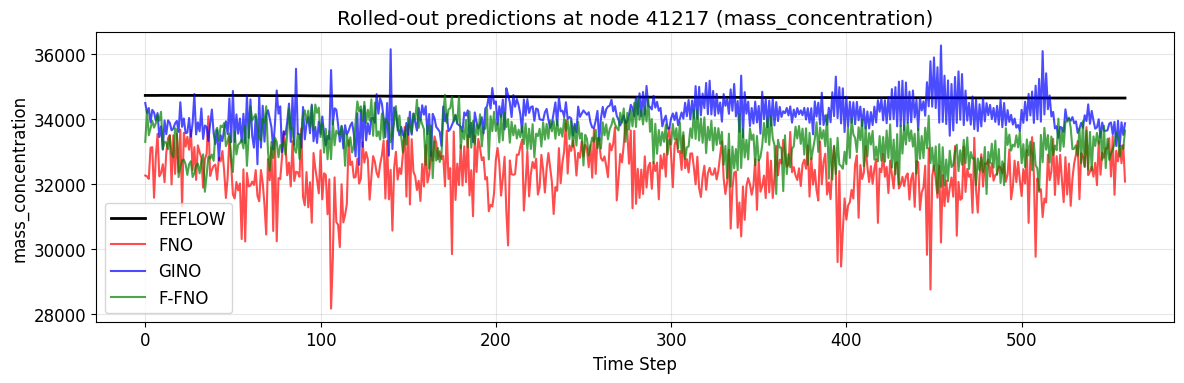

In [7]:
# --- Quick look: random node time-series for all 3 models ---
randidx = np.random.randint(gino_preds.shape[1])
colidx  = 0  # 0 = mass_concentration, 1 = head

print(f"Randomly selected node index: {randidx}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(targets[:, randidx, 0, colidx],    label='FEFLOW',  color='black',  linewidth=2)
ax.plot(fno_preds[:, randidx, 0, colidx],  label='FNO',     color='red',    alpha=0.7)
ax.plot(gino_preds[:, randidx, 0, colidx], label='GINO',    color='blue',   alpha=0.7)
ax.plot(ffno_preds[:, randidx, 0, colidx], label='F-FNO',   color='green',  alpha=0.7)
ax.set_xlabel('Time Step')
ax.set_ylabel(target_cols[colidx])
ax.set_title(f'Rolled-out predictions at node {randidx} ({target_cols[colidx]})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Compute Spatially Averaged Error over Time


In [8]:
# Derive n_steps and n_cols from loaded arrays
n_steps = gino_preds.shape[0]   # number of rolled-out time steps
n_cols  = gino_preds.shape[-1]  # number of target variables
print(f'n_steps={n_steps}, n_cols={n_cols}')

def calculate_errors_vs_time(preds, targets, n_steps, n_cols):
    rel_l2 = np.zeros((n_cols, n_steps))
    rmse = np.zeros((n_cols, n_steps))
    
    for c in range(n_cols):
        for t in range(n_steps):
            p_t = preds[t, :, 0, c]
            t_t = targets[t, :, 0, c]
            
            diff = p_t - t_t
            rmse[c, t] = np.sqrt(np.mean(diff**2))
            
            target_norm = np.linalg.norm(t_t)
            if target_norm > 1e-8:
                rel_l2[c, t] = np.linalg.norm(diff) / target_norm
            else:
                rel_l2[c, t] = np.linalg.norm(diff)
                
    return rel_l2, rmse

gino_rel_l2, gino_rmse = calculate_errors_vs_time(gino_preds, targets, n_steps, n_cols)
fno_rel_l2, fno_rmse = calculate_errors_vs_time(fno_preds, targets, n_steps, n_cols)
ffno_rel_l2, ffno_rmse = calculate_errors_vs_time(ffno_preds, targets, n_steps, n_cols)


n_steps=560, n_cols=2


## 3. Valid Prediction Horizon (VPH)


In [9]:
def compute_vph(rel_l2, threshold=0.20):
    vph = {}
    for c, col in enumerate(target_cols):
        errors = rel_l2[c]
        exceed_idx = np.where(errors > threshold)[0]
        if len(exceed_idx) > 0:
            vph[col] = exceed_idx[0]
        else:
            vph[col] = len(errors)
    return vph

gino_vph_10 = compute_vph(gino_rel_l2, threshold=0.10)
gino_vph_20 = compute_vph(gino_rel_l2, threshold=0.20)
fno_vph_10 = compute_vph(fno_rel_l2, threshold=0.10)
fno_vph_20 = compute_vph(fno_rel_l2, threshold=0.20)
ffno_vph_10 = compute_vph(ffno_rel_l2, threshold=0.10)
ffno_vph_20 = compute_vph(ffno_rel_l2, threshold=0.20)

print("--- Valid Prediction Horizon (VPH) ---")
for col in target_cols:
    print(f"\n{col}:")
    print(f"  FNO VPH @ 10% error = {fno_vph_10[col]} steps | FFNO VPH @ 10% error = {ffno_vph_10[col]} steps")
    print(f"  FNO VPH @ 20% error = {fno_vph_20[col]} steps | FFNO VPH @ 20% error = {ffno_vph_20[col]} steps")


--- Valid Prediction Horizon (VPH) ---

mass_concentration:
  FNO VPH @ 10% error = 0 steps | FFNO VPH @ 10% error = 0 steps
  FNO VPH @ 20% error = 0 steps | FFNO VPH @ 20% error = 20 steps

head:
  FNO VPH @ 10% error = 0 steps | FFNO VPH @ 10% error = 0 steps
  FNO VPH @ 20% error = 0 steps | FFNO VPH @ 20% error = 0 steps


## 4. Plot Comparative Error Accumulation


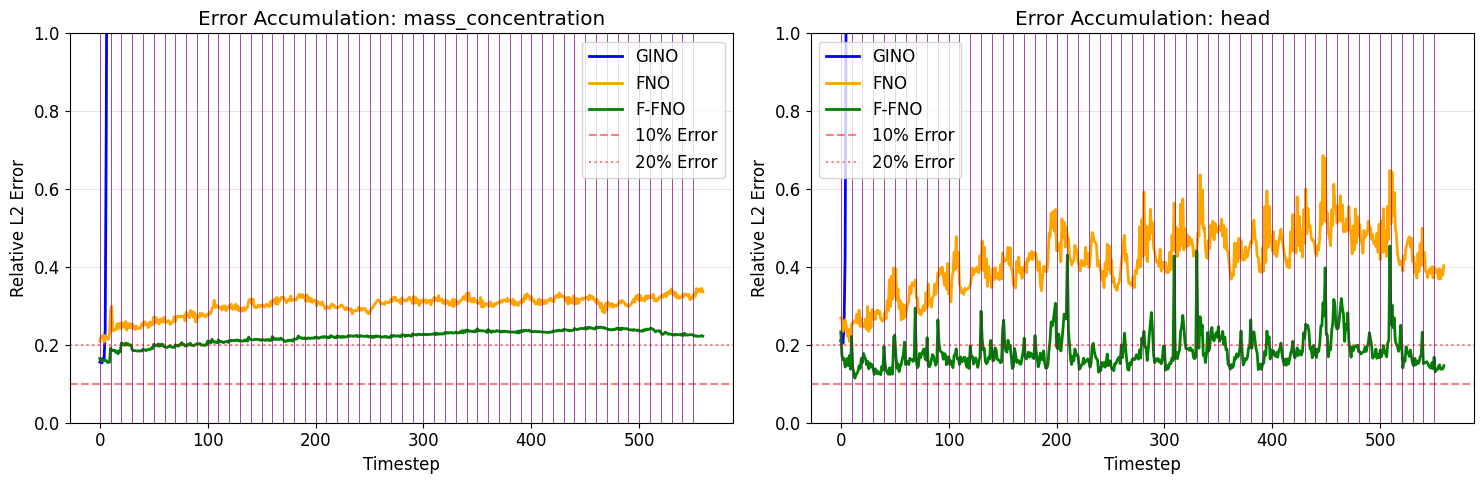

In [10]:
fig, axes = plt.subplots(1, n_cols, figsize=(15, 5))
if n_cols == 1:
    axes = [axes]

for c, col in enumerate(target_cols):
    ax = axes[c]
    ax.plot(gino_rel_l2[c], label='GINO', color='blue', linewidth=2)
    ax.plot(fno_rel_l2[c], label='FNO', color='orange', linewidth=2)
    ax.plot(ffno_rel_l2[c], label='F-FNO', color='green', linewidth=2)
    
    ax.axhline(y=0.10, color='r', linestyle='--', alpha=0.5, label='10% Error')
    ax.axhline(y=0.20, color='r', linestyle=':', alpha=0.5, label='20% Error')
    
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Relative L2 Error')
    ax.set_title(f'Error Accumulation: {col}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.0)

    for t in range(0, len(ffno_preds), 10):
        ax.axvline(x=t, linewidth=0.5, color='purple')

plt.tight_layout()
plt.show()


## 4. Replicating Error Summary and Time-Series Plots


In [11]:
# --- Re-shape Arrays for Node-wise MAE Computation ---
# Reshape from (n_steps, n_points, 1, n_cols) to (n_points, n_steps, n_cols)
gino_preds_t = gino_preds[:, :, 0, :].transpose(1, 0, 2)
fno_preds_t = fno_preds[:, :, 0, :].transpose(1, 0, 2)
ffno_preds_t = ffno_preds[:, :, 0, :].transpose(1, 0, 2)
targets_t = targets[:, :, 0, :].transpose(1, 0, 2)

print(f"Reshaped Targets shape: {targets_t.shape}")

def compute_mae(preds, obs):
    mae = []
    for idx in range(obs.shape[-1]):
        mae.append(np.mean(np.abs(preds[...,idx] - obs[...,idx]), axis=-1)/obs[...,idx].std(axis=(0, 1)))
    return np.array(mae)


Reshaped Targets shape: (61360, 560, 2)


In [12]:
# --- Compute MAE ---
fno_mae = compute_mae(fno_preds_t, targets_t)
gino_mae = compute_mae(gino_preds_t, targets_t)
ffno_mae = compute_mae(ffno_preds_t, targets_t)

print('\nMass Concentration')
print(f'FNO:\t\t{fno_mae[0].mean():.4f} + {fno_mae[0].std():.4f}')
print(f'GINO:\t\t{gino_mae[0].mean():.4f} + {gino_mae[0].std():.4f}')
print(f'FFNO:\t\t{ffno_mae[0].mean():.4f} + {ffno_mae[0].std():.4f}')

print('\nHydraulic Head')
print(f'FNO:\t\t{fno_mae[1].mean():.4f} + {fno_mae[1].std():.4f}')
print(f'GINO:\t\t{gino_mae[1].mean():.4f} + {gino_mae[1].std():.4f}')
print(f'FFNO:\t\t{ffno_mae[1].mean():.4f} + {ffno_mae[1].std():.4f}')



Mass Concentration
FNO:		0.3391 + 0.2922
GINO:		nan + nan
FFNO:		0.2186 + 0.2508

Hydraulic Head
FNO:		0.4412 + 0.4813
GINO:		nan + nan
FFNO:		0.2454 + 0.1333


In [13]:
# --- Tabular Summary ---
import pandas as pd

variables  = ['head', 'mass_concentration']
var_labels = {
    'head':               'Hydraulic Head',
    'mass_concentration': 'Mass Conc.',
}
var_mae_idx = {'head': 1, 'mass_concentration': 0}

mae_dict = {'FNO': fno_mae, 'GINO': gino_mae, 'FFNO': ffno_mae}

rows = []
for var in variables:
    idx = var_mae_idx[var]
    for model in ['FNO', 'GINO', 'FFNO']:
        rows.append({
            'Variable':        var_labels[var],
            'Model':           model,
            'NMAE_mean':       mae_dict[model][idx].mean(),
            'NMAE_std':        mae_dict[model][idx].std()
        })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))


      Variable Model  NMAE_mean  NMAE_std
Hydraulic Head   FNO   0.441232  0.481280
Hydraulic Head  GINO        NaN       NaN
Hydraulic Head  FFNO   0.245431  0.133271
    Mass Conc.   FNO   0.339093  0.292235
    Mass Conc.  GINO        NaN       NaN
    Mass Conc.  FFNO   0.218613  0.250752


Seed: 1787893227


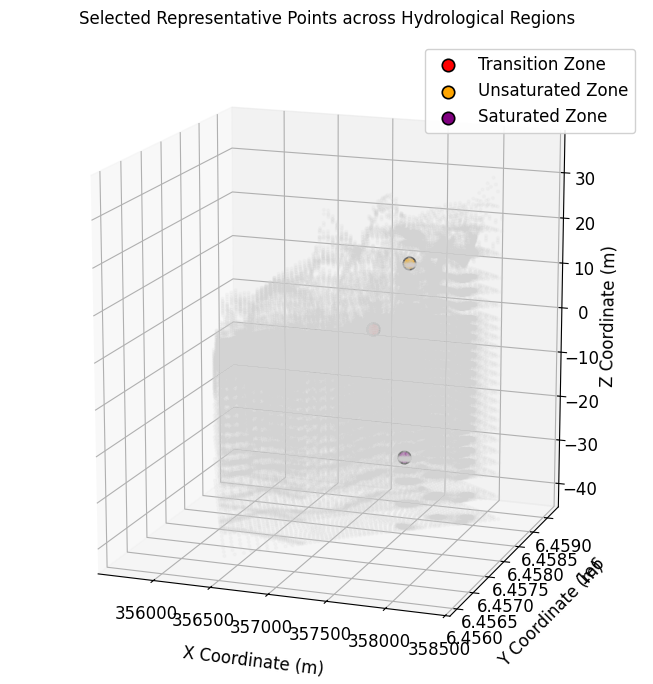

In [14]:
# --- Region-segregated comparison plots comparing FNO, GINO, and FFNO ---
import pickle
import time

# 1. Load coordinates and apply inverse coordinate transformation
dataset = 'val'
coords_path = GINO_RESULTS_DIR / f"{dataset}_coords.pkl"
coords = pickle.load(open(coords_path, "rb"))[0]
coord_mean = np.array([357225.66528974305, 6457743.243307921, -9.277822477621577])
coord_std = np.array([569.1699998979727, 566.3579737855055, 15.2656561762675])
denorm_coords = coords * coord_std + coord_mean

# 2. Extract Mass Concentration (convert from g/m3 to kg/m3 if needed)
mass_conc_targets = targets_t[..., 0] / 1000.0 if targets_t[..., 0].max() > 100 else targets_t[..., 0]

# 3. Define Region Masks (Unsaturated, Saturated, and Transition Zone)
transition_mask = (denorm_coords[:, 2] > -10) & (denorm_coords[:, 2] < 2)
unsaturated_mask = denorm_coords[:, 2] > 5
saturated_mask = (denorm_coords[:, 2] < -15) & (denorm_coords[:, 0] < 357500)

# 4. Select Representative Indices
seed = int(time.time())
np.random.seed(seed)
print(f"Seed: {seed}")

# --- Transition Zone: Capture Gradual Shift & Good FFNO Prediction ---
transition_indices = np.where(transition_mask)[0]
dynamic_ranges = np.ptp(mass_conc_targets[transition_indices, :], axis=1)

high_shift_threshold = np.percentile(dynamic_ranges, 75)
dynamic_transition_candidates = transition_indices[dynamic_ranges >= high_shift_threshold]

# Filter candidates for points where FFNO predicts reasonably well
ffno_candidate_errors = ffno_mae[0, dynamic_transition_candidates]
good_ffno_threshold = np.percentile(ffno_candidate_errors, 25)
well_predicted_transition_candidates = dynamic_transition_candidates[ffno_candidate_errors <= good_ffno_threshold]
transition_idx = np.random.choice(well_predicted_transition_candidates, size=1, replace=False)[0]

# --- Unsaturated & Saturated Zones ---
unsaturated_idx = np.random.choice(np.where(unsaturated_mask)[0], size=1, replace=False)[0]
saturated_idx = np.random.choice(np.where(saturated_mask)[0], size=1, replace=False)[0]               

# --- 3D Domain Plot highlighting the 3 selected points ---
fig = plt.figure(figsize=(9, 7))
ax3d = fig.add_subplot(111, projection="3d")
ax3d.scatter(denorm_coords[:, 0], denorm_coords[:, 1], denorm_coords[:, 2], c="lightgray", alpha=0.1, s=4)
marker_kwargs = {"s": 80, "alpha": 1.0, "edgecolors": "black", "linewidths": 1.2, "zorder": 10}

ax3d.scatter(denorm_coords[transition_idx, 0], denorm_coords[transition_idx, 1], denorm_coords[transition_idx, 2], c="red", label="Transition Zone", **marker_kwargs)
ax3d.scatter(denorm_coords[unsaturated_idx, 0], denorm_coords[unsaturated_idx, 1], denorm_coords[unsaturated_idx, 2], c="orange", label="Unsaturated Zone", **marker_kwargs)
ax3d.scatter(denorm_coords[saturated_idx, 0], denorm_coords[saturated_idx, 1], denorm_coords[saturated_idx, 2], c="purple", label="Saturated Zone", **marker_kwargs)

ax3d.set_title("Selected Representative Points across Hydrological Regions", fontsize=12, pad=12)
ax3d.set_xlabel("X Coordinate (m)", labelpad=10)
ax3d.set_ylabel("Y Coordinate (m)", labelpad=10)
ax3d.set_zlabel("Z Coordinate (m)", labelpad=5)
ax3d.legend(loc="upper right", frameon=True, framealpha=0.9)
ax3d.set_box_aspect((1, 1, 1.1))
ax3d.view_init(elev=15, azim=290)
plt.tight_layout()
plt.show()


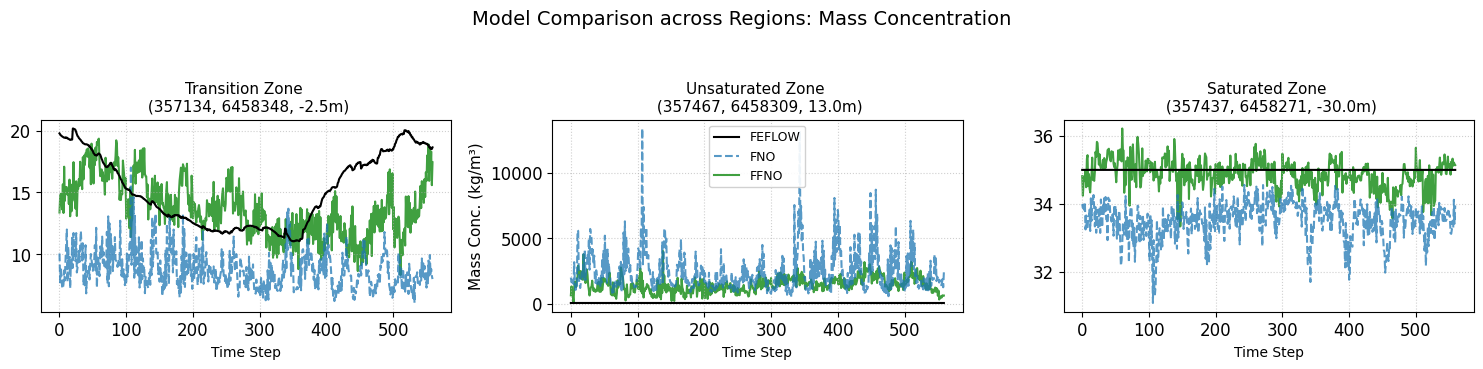

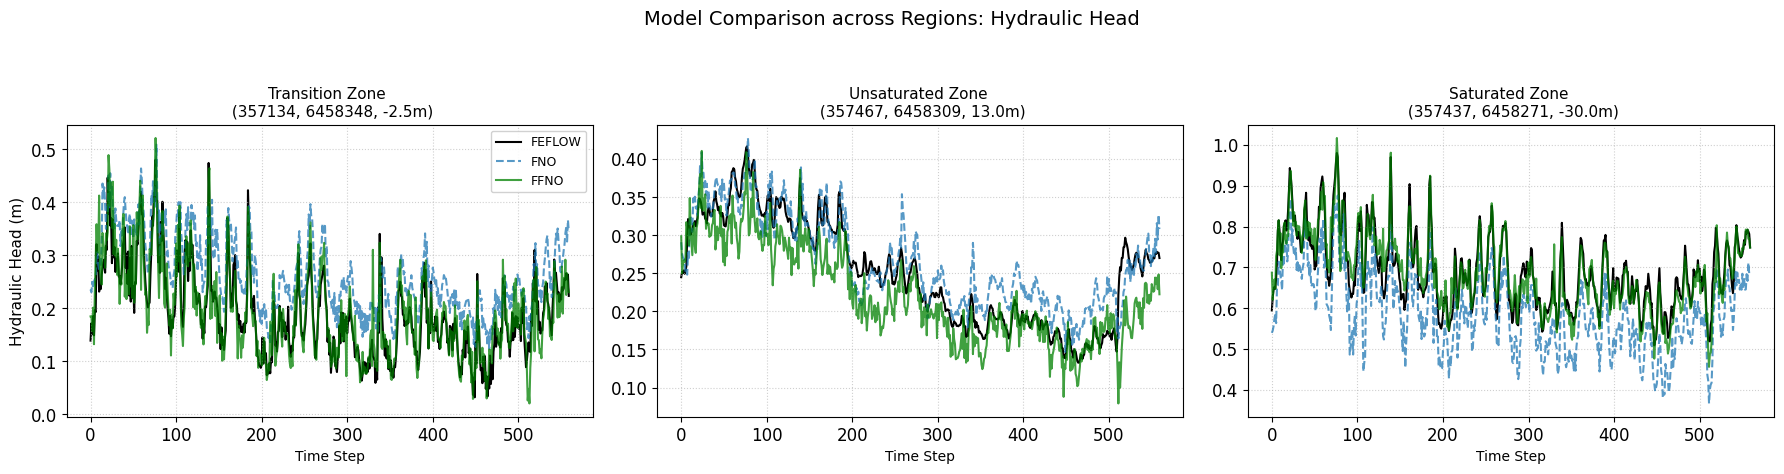

In [22]:
# --- Region-Segregated Model Comparison Plots (3 Subplots) ---
region_points = [
    ("Transition Zone", transition_idx),
    ("Unsaturated Zone", unsaturated_idx),
    ("Saturated Zone", saturated_idx)
]

# Mass Concentration Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=False)
for ax_idx, (region_name, pt_idx) in enumerate(region_points):
    ax = axes[ax_idx]
    scale = 1000.0 if targets_t[pt_idx, :, 0].max() > 100 else 1.0
    
    # Plotting actual vs predictions
    ax.plot(np.maximum(0, targets_t[pt_idx, :, 0] / scale), label="FEFLOW", color="black", linewidth=1.5, zorder=4)
    ax.plot(np.maximum(0, fno_preds_t[pt_idx, :, 0] / scale), label="FNO", linestyle="--", alpha=0.75, zorder=3)
    # ax.plot(np.maximum(0, gino_preds_t[pt_idx, :, 0] / scale), label="GINO", linestyle="-.", alpha=0.85, zorder=2)
    ax.plot(np.maximum(0, ffno_preds_t[pt_idx, :, 0] / scale), label="FFNO", linestyle="-", color="green", alpha=0.75, zorder=1)
    
    coord_str = f"({denorm_coords[pt_idx, 0]:.0f}, {denorm_coords[pt_idx, 1]:.0f}, {denorm_coords[pt_idx, 2]:.1f}m)"
    ax.set_title(f"{region_name} \n {coord_str}", fontsize=11)
    ax.set_xlabel("Time Step", fontsize=10)
    
    if ax_idx == 1:
        ax.set_ylabel("Mass Conc. (kg/m³)", fontsize=11)
        ax.legend(loc="upper center", fancybox=True, framealpha=0.9, fontsize=9)
        
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Model Comparison across Regions: Mass Concentration", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Hydraulic Head Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=False)
for ax_idx, (region_name, pt_idx) in enumerate(region_points):
    ax = axes[ax_idx]
    
    # Plotting actual vs predictions
    ax.plot(targets_t[pt_idx, :, 1], label="FEFLOW", color="black", linewidth=1.5, zorder=1)
    ax.plot(fno_preds_t[pt_idx, :, 1], label="FNO", linestyle="--", alpha=0.75, zorder=2)
    # ax.plot(gino_preds_t[pt_idx, :, 1], label="GINO", linestyle="-.", alpha=0.85, zorder=3)
    ax.plot(ffno_preds_t[pt_idx, :, 1], label="FFNO", linestyle="-", color="green", alpha=0.75, zorder=4)
    
    coord_str = f"({denorm_coords[pt_idx, 0]:.0f}, {denorm_coords[pt_idx, 1]:.0f}, {denorm_coords[pt_idx, 2]:.1f}m)"
    ax.set_title(f"{region_name} \n {coord_str}", fontsize=11)
    ax.set_xlabel("Time Step", fontsize=10)
    
    if ax_idx == 0:
        ax.set_ylabel("Hydraulic Head (m)", fontsize=11)
        ax.legend(loc="best", fancybox=True, framealpha=0.9, fontsize=9)
        
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Model Comparison across Regions: Hydraulic Head", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


## 5. Cross-Section Plot: Mass Concentration at Final Rolled-Out Time Step


In [16]:
# ============================================================
# CROSS-SECTION SETUP: Parse FEM mesh and build slice geometry
# (Uses denorm_coords already computed above)
# ============================================================
import matplotlib.tri as mtri
import matplotlib.colors as mcolors
from scipy.spatial import KDTree

# --- Transect endpoints (same as cross_section_analysis.ipynb) ---
p1_cs = np.array([356835.28, 6459067.43])
p2_cs = np.array([357877.28, 6457548.86])

dx_L = p2_cs[0] - p1_cs[0]
dy_L = p2_cs[1] - p1_cs[1]
length_cs = np.hypot(dx_L, dy_L)

print("Parsing FEFLOW ASCII mesh ...")
file_path = '/scratch/yl75/ak4177/data/feflow_data/ascii_mesh.fem'
n2d = 2360
elements_2d = []
coor_vals = []
in_node = False
in_coor = False

with open(file_path, 'r', errors='ignore') as f:
    for line in f:
        l = line.strip()
        if l == 'NODE':
            in_node = True; continue
        if in_node and (len(l) > 0 and l[0].isalpha() and l[0].isupper()):
            in_node = False
        elif in_node:
            nodes = [int(n) - 1 for n in l.split()]
            if nodes[0] < n2d:
                elements_2d.append(nodes[:3])
        if l == 'COOR':
            in_coor = True; continue
        if in_coor and (len(l) > 0 and l[0].isalpha() and l[0].isupper()):
            in_coor = False
        elif in_coor:
            for p in l.split(','):
                if p.strip():
                    coor_vals.append(float(p))

x_mesh = np.array(coor_vals[:n2d])
y_mesh = np.array(coor_vals[n2d:2*n2d])

# Align mesh coordinates to the denorm_coords space
shift_x = denorm_coords[:, 0].min() - x_mesh.min()
shift_y = denorm_coords[:, 1].min() - y_mesh.min()
x_utm = x_mesh + shift_x
y_utm = y_mesh + shift_y
xy_2d = np.column_stack((x_utm, y_utm))
print(f"Extracted {len(elements_2d)} 2D triangles.")

# Map 3D nodes to 2D footprint (26 vertical layers each)
num_slices = 26
tree_2d = KDTree(denorm_coords[:, :2])
_, indices_all = tree_2d.query(xy_2d, k=num_slices)
mapped_indices = np.zeros((n2d, num_slices), dtype=int)
for i in range(n2d):
    z_sorted = np.argsort(denorm_coords[indices_all[i], 2])
    mapped_indices[i] = indices_all[i][z_sorted]
print("Vertical topology mapped.")

# Find which 2D triangles the transect slices through
intersecting_panels = []
for elem in elements_2d:
    pts = xy_2d[elem]
    hits = []
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        A, B = pts[i], pts[j]
        dx_E = B[0] - A[0]; dy_E = B[1] - A[1]
        det = dx_L * dy_E - dy_L * dx_E
        if abs(det) < 1e-10:
            continue
        dx_AP = A[0] - p1_cs[0]; dy_AP = A[1] - p1_cs[1]
        t_L = (dx_AP * dy_E - dy_AP * dx_E) / det
        t_E = (dx_AP * dy_L - dy_AP * dx_L) / det
        if 0 <= t_L <= 1 and -1e-5 <= t_E <= 1 + 1e-5:
            hits.append((t_L, t_E, elem[i], elem[j]))
    if len(hits) >= 2:
        hits.sort(key=lambda x: x[0])
        h1, h2 = hits[0], hits[-1]
        if h2[0] - h1[0] > 1e-5:
            intersecting_panels.append({
                's1': h1[0] * length_cs, 'w1': h1[1], 'e1': (h1[2], h1[3]),
                's2': h2[0] * length_cs, 'w2': h2[1], 'e2': (h2[2], h2[3])
            })
print(f"Transect cuts through {len(intersecting_panels)} elements.")


Parsing FEFLOW ASCII mesh ...
Extracted 4564 2D triangles.
Vertical topology mapped.
Transect cuts through 91 elements.


In [17]:
# ============================================================
# BUILD CROSS-SECTION GEOMETRY AT LAST TIME STEP
# ============================================================

# Extract mass concentration at the LAST rolled-out timestep for each model
# targets_t / fno_preds_t / gino_preds_t / ffno_preds_t are (n_points, n_steps, n_cols)
# col 0 = mass concentration
mc_target_start = np.clip(targets_t[:, 0, 0], 0, None)
mc_fno_start    = np.clip(fno_preds_t[:, 0, 0], 0, None)
mc_gino_start   = np.clip(gino_preds_t[:, 0, 0], 0, None)
mc_ffno_start   = np.clip(ffno_preds_t[:, 0, 0], 0, None)

mc_target_end = np.clip(targets_t[:, -1, 0], 0, None)
mc_fno_end    = np.clip(fno_preds_t[:, -1, 0], 0, None)
mc_gino_end   = np.clip(gino_preds_t[:, -1, 0], 0, None)
mc_ffno_end   = np.clip(ffno_preds_t[:, -1, 0], 0, None)

def build_cross_section(mc_vals_dict, mapped_indices, intersecting_panels, denorm_coords, num_slices):
    # Build triangulated cross-section arrays for multiple scalar fields.
    s_coords = []
    z_coords = []
    triangles = []
    field_vals = {k: [] for k in mc_vals_dict}
    node_counter = 0

    for panel in intersecting_panels:
        s1, w1, e1 = panel['s1'], panel['w1'], panel['e1']
        s2, w2, e2 = panel['s2'], panel['w2'], panel['e2']

        for k in range(num_slices):
            idx_n1a = mapped_indices[e1[0], k]
            idx_n1b = mapped_indices[e1[1], k]
            idx_n2a = mapped_indices[e2[0], k]
            idx_n2b = mapped_indices[e2[1], k]

            z1 = denorm_coords[idx_n1a, 2] + w1 * (denorm_coords[idx_n1b, 2] - denorm_coords[idx_n1a, 2])
            z2 = denorm_coords[idx_n2a, 2] + w2 * (denorm_coords[idx_n2b, 2] - denorm_coords[idx_n2a, 2])

            s_coords.extend([s1, s2])
            z_coords.extend([z1, z2])

            for key, mc in mc_vals_dict.items():
                v1 = mc[idx_n1a] + w1 * (mc[idx_n1b] - mc[idx_n1a])
                v2 = mc[idx_n2a] + w2 * (mc[idx_n2b] - mc[idx_n2a])
                field_vals[key].extend([v1, v2])

            if k > 0:
                b1, b2 = node_counter - 2, node_counter - 1
                t1, t2 = node_counter, node_counter + 1
                triangles.append([b1, b2, t1])
                triangles.append([b2, t2, t1])

            node_counter += 2

    s_arr = np.array(s_coords)
    z_arr = np.array(z_coords)
    tri_arr = np.array(triangles)
    field_arr = {}
    for k, v in field_vals.items():
        arr = np.array(v)
        # Replace any NaN/Inf that can arise from interpolation near mesh boundaries
        arr = np.nan_to_num(arr, nan=0.0, posinf=35000.0, neginf=0.0)
        arr = np.clip(arr, 0, 35000)
        field_arr[k] = arr

    return s_arr, z_arr, tri_arr, field_arr

mc_fields = {
    'FEFLOW-start': mc_target_start,
    'FNO-start':    mc_fno_start,
    'GINO-start':   mc_gino_start,
    'FFNO-start':   mc_ffno_start,
    'FEFLOW-end': mc_target_end,
    'FNO-end':    mc_fno_end,
    'GINO-end':   mc_gino_end,
    'FFNO-end':   mc_ffno_end,
}

s_cs, z_cs, tri_cs, field_cs = build_cross_section(
    mc_fields, mapped_indices, intersecting_panels, denorm_coords, num_slices
)
triangulation_cs = mtri.Triangulation(s_cs, z_cs, tri_cs)
print(f"Cross-section mesh built: {len(tri_cs)} triangles, {len(s_cs)} vertices.")

# Sanity check
for model, vals in field_cs.items():
    n_bad = (~np.isfinite(vals)).sum()
    print(f"  {model}: min={vals.min():.1f}, max={vals.max():.1f}, non-finite={n_bad}")


Cross-section mesh built: 4550 triangles, 4732 vertices.
  FEFLOW-start: min=0.0, max=35000.0, non-finite=0
  FNO-start: min=335.6, max=35000.0, non-finite=0
  GINO-start: min=0.0, max=35000.0, non-finite=0
  FFNO-start: min=0.0, max=35000.0, non-finite=0
  FEFLOW-end: min=22.6, max=35000.0, non-finite=0
  FNO-end: min=219.6, max=35000.0, non-finite=0
  GINO-end: min=0.0, max=35000.0, non-finite=0
  FFNO-end: min=0.0, max=35000.0, non-finite=0


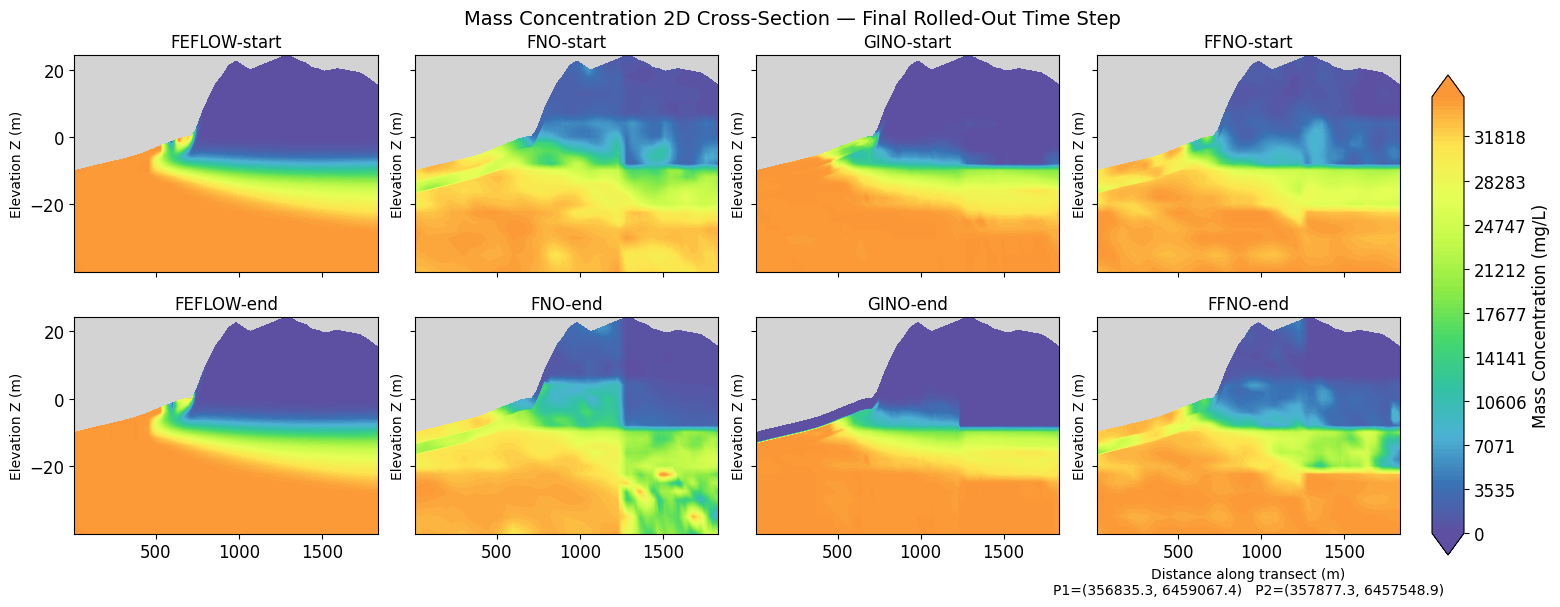

In [18]:
# ============================================================
# PLOT: 4-panel cross-section comparison at final time step
# ============================================================
feflow_colors = [
    '#5E4FA2',  # < 0       Purple
    '#3973B5',  # 0-1000    Medium Blue
    '#4CB2D4',  # 1000-5000 Cyan
    '#32C2A3',  # 5000-10000 Teal
    '#45D86A',  # 10000-15000 Light Green
    '#8DEB45',  # 15000-20000 Lime Green
    '#C4FA4B',  # 20000-25000 Yellow-Green
    '#E7FE57',  # 25000-30000 Pale Yellow
    '#FEE44F',  # 30000-34500 Golden Yellow
    '#FB9736',  # > 34500   Orange
]
cmap_cs = mcolors.LinearSegmentedColormap.from_list('feflow_continuous', feflow_colors)
norm_cs = mcolors.Normalize(vmin=0, vmax=35000)
contour_kwargs = dict(levels=np.linspace(0, 35000, 100), cmap=cmap_cs, norm=norm_cs, extend='both')

models = ['FEFLOW-start', 'FNO-start', 'GINO-start', 'FFNO-start',
          'FEFLOW-end', 'FNO-end', 'GINO-end', 'FFNO-end']
# titles = [
#     'FEFLOW (Ground Truth)',
#     'FNO (Rolled Out)',
#     'GINO (Rolled Out)',
#     'FFNO (Rolled Out)',
# ]

titles = models.copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)

for ax, model, title in zip(axes.flatten(), models, titles):
    cf = ax.tricontourf(triangulation_cs, field_cs[model], **contour_kwargs)
    ax.set_title(title, fontsize=12, pad=6)
    ax.set_ylabel('Elevation Z (m)', fontsize=10)
    ax.set_facecolor('lightgrey')

axes[-1, -1].set_xlabel(
    f'Distance along transect (m)\nP1=({p1_cs[0]:.1f}, {p1_cs[1]:.1f})   P2=({p2_cs[0]:.1f}, {p2_cs[1]:.1f})',
    fontsize=10
)

plt.xlim(s_cs.min(), s_cs.max())
plt.ylim(z_cs.min(), z_cs.max())
plt.tight_layout()
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.10, 0.02, 0.80])
cbar = fig.colorbar(cf, cax=cbar_ax, label='Mass Concentration (mg/L)', extend='both')
plt.suptitle(
    'Mass Concentration 2D Cross-Section — Final Rolled-Out Time Step',
    fontsize=14, y=1.01
)
plt.show()


## 6. Depth Profile Analysis: Mass Concentration Error vs Z Coordinate


Nodes with non-zero target signal: 61360 / 61360
  FNO: signed_err mean=-661.14, mae mean=5073.44, l2 mean=84109.5363
  GINO: signed_err mean=nan, mae mean=nan, l2 mean=nan
  FFNO: signed_err mean=367.59, mae mean=3247.11, l2 mean=63938.6039


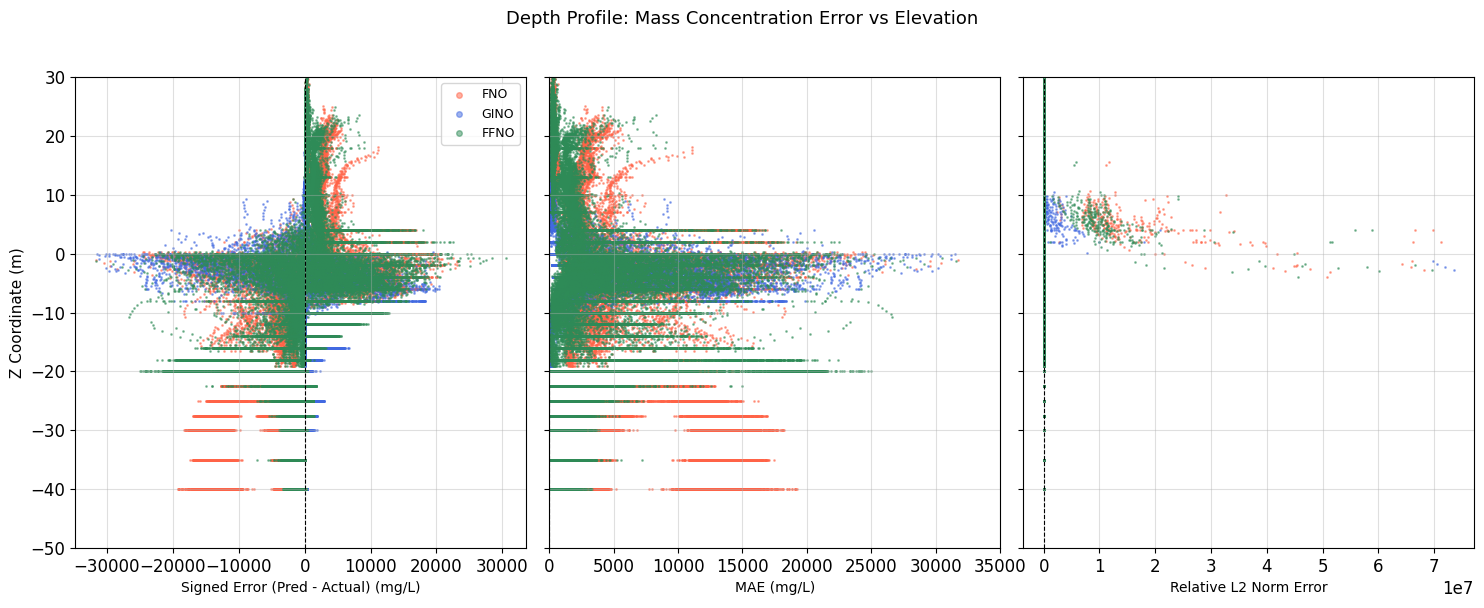

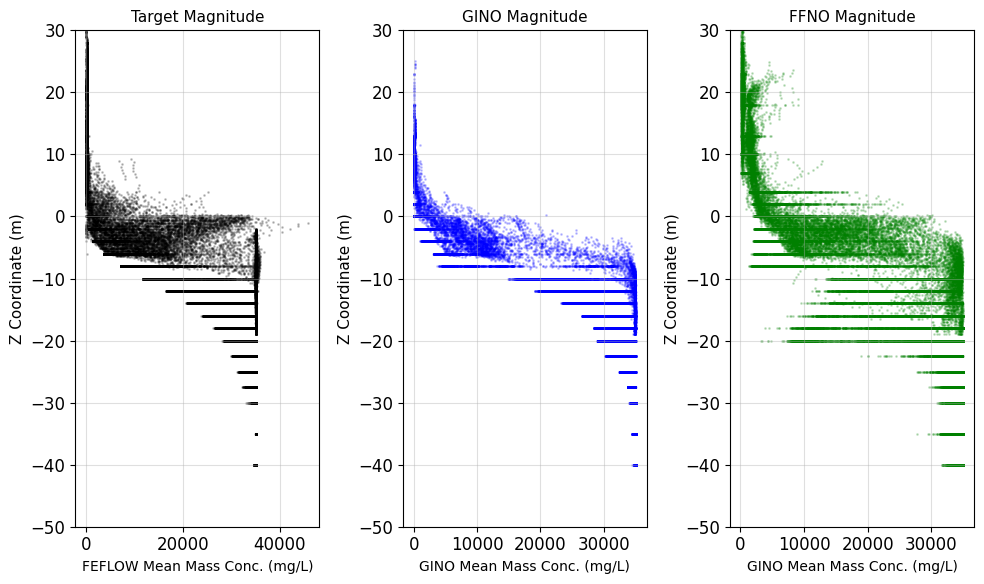

In [24]:
# ============================================================
# DEPTH PROFILE ANALYSIS
# Compare predicted vs FEFLOW mass concentration error
# across the depth (Z coordinate) for all models.
#
# Uses: targets_t, fno_preds_t, gino_preds_t, ffno_preds_t
#       shape (n_points, n_steps, n_cols)  col 0 = mass_concentration
#       denorm_coords shape (n_points, 3)  col 2 = Z elevation
# ============================================================

# --- Per-node metric functions over the time axis ---
def dp_signed_error(preds, targets):
    # Mean signed error per node over all time steps (pred - actual).
    return np.mean(preds - targets, axis=1)

def dp_mae(preds, targets):
    # Mean absolute error per node over all time steps.
    return np.mean(np.abs(preds - targets), axis=1)

def dp_l2_norm_error(preds, targets):
    # Relative L2 norm error per node over all time steps.
    num = np.linalg.norm(preds - targets, ord=2, axis=1)
    den = np.linalg.norm(targets, ord=2, axis=1)
    return np.where(den > 1e-8, num / den, num)

# Extract mass concentration time-series per node (col 0)
# Shape: (n_points, n_steps)
mc_target_ts = targets_t[:, :, 0]
mc_fno_ts    = np.clip(fno_preds_t[:, :, 0], 0.01, 35000)
mc_gino_ts   = np.clip(gino_preds_t[:, :, 0], 0.01, 35000)
mc_ffno_ts   = np.clip(ffno_preds_t[:, :, 0], 0.01, 35000)

# Per-node mean target magnitude (used as reference for filter)
mean_mc_target = np.mean(mc_target_ts, axis=1)
mean_mc_ffno = np.mean(mc_ffno_ts, axis=1)
mean_mc_gino = np.mean(mc_gino_ts, axis=1)

# Compute per-node metrics for each model
models_ts = {
    'FNO':    mc_fno_ts,
    'GINO':   mc_gino_ts,
    'FFNO':   mc_ffno_ts,
}

metrics = {}
for model, pred_ts in models_ts.items():
    metrics[model] = {
        'signed_err': dp_signed_error(pred_ts, mc_target_ts),
        'mae':        dp_mae(pred_ts, mc_target_ts),
        'l2':         dp_l2_norm_error(pred_ts, mc_target_ts),
    }

z_coords = denorm_coords[:, 2]

# Only plot nodes where target has non-trivial signal
filter_mask = np.ones_like(mean_mc_target, dtype=bool)

print(f"Nodes with non-zero target signal: {filter_mask.sum()} / {len(filter_mask)}")
for model, m in metrics.items():
    print(f"  {model}: signed_err mean={m['signed_err'][filter_mask].mean():.2f}, "
          f"mae mean={m['mae'][filter_mask].mean():.2f}, "
          f"l2 mean={m['l2'][filter_mask].mean():.4f}")

# --- Plot ---
model_list  = ['FNO', 'GINO', 'FFNO']
model_colors = {'FNO': 'tomato', 'GINO': 'royalblue', 'FFNO': 'seagreen'}
scatter_kw = dict(alpha=0.5, s=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

panel_cfg = [
    ('signed_err', 'Signed Error (Pred - Actual) (mg/L)'),
    ('mae',        'MAE (mg/L)'),
    ('l2',         'Relative L2 Norm Error'),
]

for col_idx, (metric_key, xlabel) in enumerate(panel_cfg):
    ax = axes[col_idx]
    for model in model_list:
        vals = metrics[model][metric_key][filter_mask]
        ax.scatter(vals, z_coords[filter_mask],
                   label=model, color=model_colors[model], **scatter_kw)
    ax.axvline(x=0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylim(-50, 30)
    ax.grid(True, alpha=0.4)
    if col_idx == 1:
        ax.set_xlim(0, 35000)
    if col_idx == 0:
        ax.set_ylabel('Z Coordinate (m)', fontsize=11)
        ax.legend(loc='upper right', fontsize=9, markerscale=4)

# Add FEFLOW target magnitude as 4th reference panel
fig2, axes = plt.subplots(1, 3, figsize=(10, 6))

axes[0].scatter(mean_mc_target[filter_mask], z_coords[filter_mask],
            alpha=0.2, s=1, color='black')
axes[0].set_xlabel('FEFLOW Mean Mass Conc. (mg/L)', fontsize=10)
axes[0].set_ylabel('Z Coordinate (m)', fontsize=11)
axes[0].set_ylim(-50, 30)
axes[0].grid(True, alpha=0.4)
axes[0].set_title('Target Magnitude', fontsize=11)

axes[1].scatter(mean_mc_gino[filter_mask], z_coords[filter_mask],
            alpha=0.2, s=1, color='blue')
axes[1].set_xlabel('GINO Mean Mass Conc. (mg/L)', fontsize=10)
axes[1].set_ylabel('Z Coordinate (m)', fontsize=11)
axes[1].set_ylim(-50, 30)
axes[1].grid(True, alpha=0.4)
axes[1].set_title('GINO Magnitude', fontsize=11)

axes[2].scatter(mean_mc_ffno[filter_mask], z_coords[filter_mask],
            alpha=0.2, s=1, color='green')
axes[2].set_xlabel('GINO Mean Mass Conc. (mg/L)', fontsize=10)
axes[2].set_ylabel('Z Coordinate (m)', fontsize=11)
axes[2].set_ylim(-50, 30)
axes[2].grid(True, alpha=0.4)
axes[2].set_title('FFNO Magnitude', fontsize=11)


fig.suptitle('Depth Profile: Mass Concentration Error vs Elevation', fontsize=13, y=1.01)
fig.tight_layout()
fig.show()
fig2.tight_layout()
fig2.show()
